# Régression sur des images et régularisation

On a fait dans les derniers modules une version assez traditionnelle de la régression, mais comprenez bien que le terme *régression* s'applique sur *n'importe quelle tâche qui vise à prédire des valeurs ordonnées/numériques*.

On peut très bien appliquer ça à des **images** : si on prédisait la **valeur d'un pixel**, on parlerait encore de régression.

&nbsp;

On va partir d'un jeu de données qui contient des *dessins de visages* :

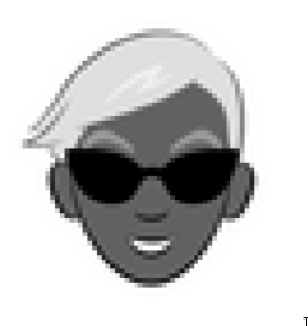


In [1]:
#@title Importations et méthodes
import numpy as np
import pandas as pd
import plotly.express as px

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

def imshow(matrice, titre="(Image sans titre)", subplot=None):
  axis = plt
  if subplot is not None:
    axis = subplot
  matrice = np.clip(matrice, 0, 1)
  axis.imshow(matrice, cmap="gray", vmin=0, vmax=1)
  if subplot is None:
    axis.title(titre)
    axis.show()

In [2]:
#@title Téléchargement des dessins
!(test -e cartoonset10k.pkl && echo "Fichier prêt") || (wget https://raw.githubusercontent.com/316k/misc-data/refs/heads/main/cartoonset10k.pkl.gz -O cartoonset10k.pkl.gz && gunzip "cartoonset10k.pkl.gz")

Fichier prêt


In [3]:
#@title Chargement et visualisation du jeu de données
import pickle
with open("cartoonset10k.pkl", "rb") as f:
    faces = pickle.load(f) # Liste python de matrices numpy

HAUTEUR_IMG, LARGEUR_IMG = faces[0].shape

def afficher_image(i=0):
  imshow(faces[i], f"Image #{i}")

from ipywidgets import interact

output = interact(afficher_image, i=(0, len(faces)-1))

interactive(children=(IntSlider(value=0, description='i', max=9999), Output()), _dom_classes=('widget-interact…

## Problème à résoudre : complétion de visages

Voici le problème qu'on va chercher à résoudre : étant donné une moitié de visage, comme

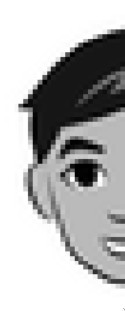

on veut prédire l'autre moitié :

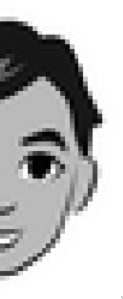

## Démarche

On va approcher le problème comme celui d'une **régression multiple** : les pixels à prédire à droite seront comme une régression avec N valeurs de sortie, en utilisant les pixels de l'image de gauche comme variables d'entrée.

On va avoir besoin de :

- Préparer les données pour les fournir à `sklearn`
    - Mettre les images dans un format utilisable par `sklearn`
    - Séparer les données en entraînement/validation/test
- Entraîner des algorithmes de régression
- Évaluer l'erreur de validation commise par les différents algorithmes et choisir le meilleur

## Préparer les données

Notre tâche demande :

- En entrée $X$, tous les pixels du côté gauche de l'image
- Comme prédiction $y$, tous les pixels du côté droit de l'image

Chaque prédiction $y$ sera donc un **vecteur à plusieurs dimensions** (autant de dimensions que de pixels dans l'image de droite).

Une approche simple ici serait de construire $N$ régressions linéaires, une régression linéaire différente pour chaque pixel.

&nbsp;

Heureusement pour nous, on n'aura pas à le faire à la main : `scikit-learn` supporte très facilement ce format de problème.

On n'a qu'à utiliser :

- `X = DataFrame 2D`, où chaque ligne est le côté gauche d'une image, applatie en 1D
- `y = DataFrame 2D`, où chaque ligne est le côté droit de cette image, également applatie en 1D.

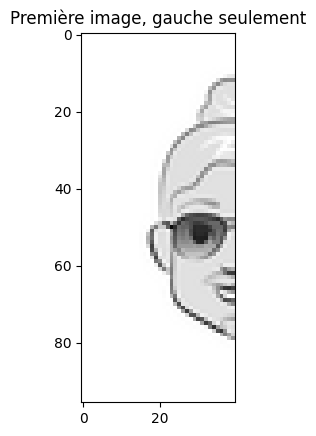

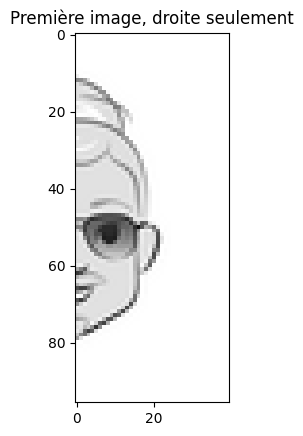

In [4]:
#@title Exercice 1 : Extraire les moitiés gauches et les moitiés droites

# La variable faces contient une liste de matrices 2D numpy
# Construisez deux listes qui contiennent des matrices 2D numpy, une avec chaque moitié de face
moities_gauches = []
moities_droites = []

# Vous aurez besoin de faire une boucle for sur toutes les faces et d'utiliser les slices en 2D

#####

for face in faces:
  moities_gauches.append(face[:, :LARGEUR_IMG//2])
  moities_droites.append(face[:, LARGEUR_IMG//2:])

##### tests

# Affichages de test

imshow(moities_gauches[0], "Première image, gauche seulement")
imshow(moities_droites[0], "Première image, droite seulement")

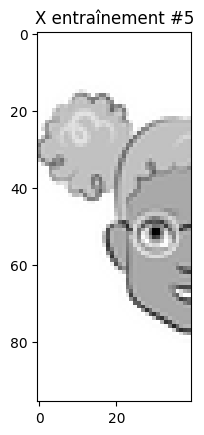

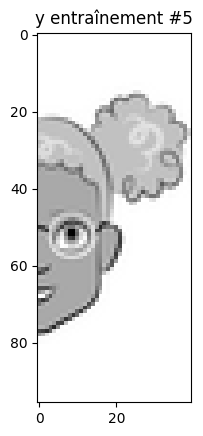

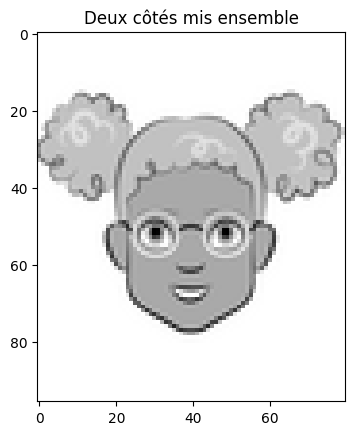

In [5]:
#@title Exercice 2 : construire les X, y d'entraînement, de validation et de test

# On va commencer par construire les X et y pour toutes les 10 000 images, le code
# fourni à la fin sera utilisé pour séparer tout ça en
# trois sous-ensembles entraînement/validation/test

################

### X = les données fournies à l'algo pour faire sa prédiction
###   = un tableau où chaque ligne contient les pixels de gauche de l'image, écrasés en 1D
### Le format de la variable X est un tableau numpy 2D de taille:
###      10_000 exemples x nombre de pixels dans la moitié gauche
X = np.zeros((10_000, moities_gauches[0].size))

### y = des exemples de prédictions idéales
###   = un tableau où chaque ligne contient les pixels de droite de l'image, écrasés en 1D
### Le format de la variable X est un tableau numpy 2D de taille:
###      10_000 exemples x nombre de pixels à droite
y = np.zeros((10_000, moities_droites[0].size))


### Faites une boucle sur chaque image de moities_gauches
### Dans chaque ligne, prenez l'image, écrasez-la en 1D avec .reshape()
### et assignez cette valeur à la i-ème ligne de X

### Refaites la même chose pour les moities_droites mais dans la variable y

###################

i = 0
for image in moities_gauches:
  X[i, :] = image.reshape(LARGEUR_IMG * HAUTEUR_IMG // 2)
  i += 1

i = 0

for image in moities_droites:
  y[i, :] = image.reshape(LARGEUR_IMG * HAUTEUR_IMG // 2)
  i += 1

############# tests

# On a un total de 10 000 dessins. On va utiliser:
# 6 000 images d'entraînement
# 2 000 images de validation (pour choisir le meilleur algorithme)
# 2 000 images de test (pour estimer l'erreur à la fin)
X_entrainement = X[:5_000, :]
X_validation = X[5_000:6_000, :]
X_test = X[6_000:7_000, :]

y_entrainement = y[:5_000, :]
y_validation = y[5_000:6_000, :]
y_test = y[6_000:7_000, :]

# Si tout a fonctionné, cette méthode devrait vous permettre
def afficher_visage(visage1D, titre=None):
  img = visage1D.reshape(HAUTEUR_IMG, LARGEUR_IMG // 2)
  imshow(img, titre)

def afficher_deux_cotes(gauche1D, droite1D, titre=None, plt=None):
  gauche = gauche1D.reshape(HAUTEUR_IMG, LARGEUR_IMG // 2)
  droite = droite1D.reshape(HAUTEUR_IMG, LARGEUR_IMG // 2)
  img = np.concat([gauche, droite], axis=1)
  imshow(img, titre, subplot=plt)

afficher_visage(X_entrainement[5], "X entraînement #5")
afficher_visage(y_entrainement[5], "y entraînement #5")
afficher_deux_cotes(X_entrainement[5], y_entrainement[5], "Deux côtés mis ensemble")

## Entraîner et évaluer des algorithmes de régression

On a vu deux algorithmes de régression pour le moment :

- `LinearRegression()`
- `KNeighborsRegressor()`

a priori, les deux pourraient fonctionner.

&nbsp;

*Petite question* : comment devrait-on choisir la valeur de $K$ à utiliser avec la régression de KNN?

La réponse est assez simple : **on en entraîne plusieurs** et on regarde l'**erreur obtenue sur l'ensemble de validation**.

&nbsp;

**Terminologie** :

- Un **paramètre** est une valeur apprise par l'algorithme qu'on utilise. Dans le cas d'une régression linéaire simple, $y = mx + b$, les paramètres étaient $m$ et $b$, car ils étaient appris à partir des données d'entraînement
- Le $K$ de KNN n'est **PAS** appris. Il est choisi arbitrairement, potentiellement en testant plusieurs différentes configurations. On appelle de telles valeurs un **hyperparamètre**.

La régression linéaire n'a pas d'hyperparamètre, mais c'est un terme qui va revenir dans les prochains algorithmes qu'on va voir.

&nbsp;

On va tester deux algorithmes différents, avec différentes configurations d'hyperparamètres, pour un total de 4 combinaisons :

- Régression linéaire
- KNN avec K=1
- KNN avec K=6
- KNN avec K=25

&nbsp;

Pour l'évaluation de la qualité des prédictions, on va faire deux choses :

1. Regarder l'erreur RMSE
2. Inspecter le résultat visuellement pour plusieurs images

L'erreur RMSE sera calculée en comparant une prédiction d'image pixel à pixel avec l'image attendue. Ça nous donnera un indicateur numérique pour comparer.

Puisque notre tâche est visuelle, on va également inspecter le résultat avec nos yeux. Ça va être important de vérifier que les résultats sont visuellement jolis.

In [6]:
#@title Exercice 3

# Complétez la méthode qui entraîne + évalue un modèle
def entrainer_evaluer(modele):
  # 1. Appelez fit() avec les données d'entraînement
  ...

  # 2. Appelez predict() avec les données d'entraînement
  # Refaites la même chose avec les données de validation
  ...

  # 3. Affichez l'erreur RMSE d'entraînement avec print(),
  # en calculant ça avec root_mean_squared_error()
  ...

  # 3. Affichez l'erreur RMSE de validation de la même façon
  ...


#############

def entrainer_evaluer(modele):
  # 1. Appelez fit() avec les données d'entraînement
  modele.fit(X_entrainement, y_entrainement)

  y_predictions_validation = modele.predict(X_validation)
  y_predictions_entrainement = modele.predict(X_entrainement)

  print("Erreur RMSE d'entraînement:", root_mean_squared_error(y_entrainement, y_predictions_entrainement))
  print("Erreur RMSE de validation:", root_mean_squared_error(y_validation, y_predictions_validation))


######### tests

# On appellera la méthode avec les modèles suivants
modeles = [
  LinearRegression(),
  KNeighborsRegressor(1),
  KNeighborsRegressor(6),
  KNeighborsRegressor(25),
]

for modele in modeles:
  print(modele)
  entrainer_evaluer(modele)

LinearRegression()
Erreur RMSE d'entraînement: 0.0016967125509513832
Erreur RMSE de validation: 0.026722493911353954
KNeighborsRegressor(n_neighbors=1)
Erreur RMSE d'entraînement: 0.0
Erreur RMSE de validation: 0.051065377426495306
KNeighborsRegressor(n_neighbors=6)
Erreur RMSE d'entraînement: 0.03536152733122336
Erreur RMSE de validation: 0.041588415833954465
KNeighborsRegressor(n_neighbors=25)
Erreur RMSE d'entraînement: 0.04986497936787545
Erreur RMSE de validation: 0.0511518624832436


L'erreur RMSE devrait déjà nous donner un indice sur la qualité des différents algorithmes :

In [7]:
df_erreurs = pd.DataFrame([
    ['RMSE entrainement', 'reg lineaire', 0.0016967125509513832],
    ['RMSE validation', 'reg lineaire', 0.026722493911353954],

    ['RMSE validation', 'KNN, K=1', 0.051065377426495306],
    ['RMSE entrainement', 'KNN, K=1', 0.0],

    ['RMSE validation', 'KNN, K=6', 0.041588415833954465],
    ['RMSE entrainement', 'KNN, K=6', 0.03536152733122336],

    ['RMSE validation', 'KNN, K=25', 0.0511518624832436],
    ['RMSE entrainement', 'KNN, K=25', 0.04986497936787545],

], columns=['type', 'variable', 'erreur'])

px.bar(df_erreurs, x='variable', y='erreur', facet_col='type')

La régression linéaire donne des résultats globalement meilleurs que le reste.

Notez l'erreur d'entraînement de KNN=1 qui est un peu étrange : elle est à zéro.

**Question de révision** : essayez d'expliquer pourquoi c'est le cas.

&nbsp;

Regarder l'erreur RMSE est important mais pas suffisant ici. Inspecter visuellement le résultat va nous en dire plus sur le *type d'erreur commise par les différents algos* :

In [8]:
def afficher_prediction(i=0):
  fig, axarr = plt.subplots(1, 5)
  axarr = np.ravel(axarr)
  # Vérité
  axarr[0].title.set_text(f"Attendu")
  afficher_deux_cotes(X_validation[i:i+1], y_validation[i], plt=axarr[0])

  # Modèles d'apprentissage
  for num, modele in enumerate(modeles):
    y_predictions = modele.predict(X_validation[i:i+1])
    idx = num + 1
    axarr[idx].title.set_text(f"{modele}".replace("KNeighborsRegressor", "KNN").replace("n_neighbors=", ''))
    afficher_deux_cotes(X_validation[i:i+1], y_predictions[0], plt=axarr[idx])
  #axarr = np.reshape(axarr, (2, 3))
  fig.set_figheight(15)
  fig.set_figwidth(15)
  fig.tight_layout()

output = interact(afficher_prediction, i=(0, len(X_validation)-1))

interactive(children=(IntSlider(value=0, description='i', max=999), Output()), _dom_classes=('widget-interact'…

**QUESTION 4.1**

Prenez le temps d'explorer les résultats et notez vos observations.

- Comment se comportent les différentes versions de KNN?
- Est-ce que la régression linéaire donne toujours des bons résultats? (La question suivante va vous aider à le voir si vous avez l'impression qu'elle est déjà parfaite...)


**RÉPONSE**

- La régression linéaire donne un résultat très proche de ce qu'on cherchait, tandis que KNN a tendence à recopier un exemple existant similaire sans généraliser plus que loin que les données déjà vues.
- La régression linéaire est très très bonne en général, mais a quelques petits cas problématiques...

**QUESTION 4.2**

Utilisez le widget ci-haut et inspectez les numéros d'images suivants :

- 13
- 253
- 528
- 33


**RÉPONSE**

Ces images ont des très gros glitches visuels...

## Interpréter la régression linéaire apprise pour comprendre le problème

Une régression linéaire est toujours dans le format :

$$\text{y} = m_1 * x_1 + m_2 * x_2 + m_3 * x_3 + ... + b$$

&nbsp;

Dans le contexte de notre image, chaque pixel à prédire suit une règle de ce type :


$$\text{pixelsDroite}_1 = m_{1,1} * \text{pixelsGauche}_1 + m_{1,2} * \text{pixelsGauche}_2 + m_{1,3} * ... + b_1$$

$$\text{pixelsDroite}_2 = m_{2,1} * \text{pixelsGauche}_1 + m_{2,2} * \text{pixelsGauche}_2 + m_{2,3} * ... + b_2$$

...

$$\text{pixelsDroite}_N = m_{N,1} * \text{pixelsGauche}_1 + m_{N,2} * \text{pixelsGauche}_2 + m_{N,3} * ... + b_N$$

&nbsp;

**On peut donc savoir, pour un pixel de droite donné, quelle est la proportion de chaque pixel de gauche considérée pour calculer le résultat**.

In [9]:
#@title Démo : visualisation des coefficients
from IPython.display import Markdown, Latex
modele_regression_lineaire = modeles[0]

# Les coefficients sont disponbiles ici:
# 3840 régressions linéaires, qui ont toutes des m_1, m_2, ... m_3840
print("Coefficients calculés:", modele_regression_lineaire.coef_.shape)

display(px.imshow(
    np.clip(modele_regression_lineaire.predict(X_validation[30:39]).reshape(9, HAUTEUR_IMG, LARGEUR_IMG//2), 0, 1),
    facet_col=0,
    color_continuous_scale='gray',
    title="Exemples d'images (passez la souris sur un pixel pour avoir les coordonnées x, y)"
))

def afficher_coefs(x=8, y=53):
  from IPython.display import clear_output
  clear_output()
  # Affichage de la formule
  coefs = modele_regression_lineaire.coef_[y * LARGEUR_IMG//2 + x, :]
  idx_plus_gros_coefs = np.argsort(np.abs(coefs))[-6:]
  px = lambda x, y: r"\text{pixel}_{("+str(x) + ", " + str(y) + ")}"
  px1d = lambda idx: px(idx//(LARGEUR_IMG//2), idx % (LARGEUR_IMG//2))
  formule = r"$$" + px(y, x) + " = "
  formule += ' + '.join(
      str(np.round(coefs[idx1d], 1)) + " " + px1d(idx1d)
      for idx1d in idx_plus_gros_coefs[::-1]
  )
  formule += "+ ... $$"
  display(Latex(formule))

  # Affichage de l'image
  image_coefs = np.abs(modele_regression_lineaire.coef_[y * LARGEUR_IMG//2 + x, :])
  if (image_coefs.max() - image_coefs.min()) > 0:
    image_coefs = (image_coefs - image_coefs.min()) / (image_coefs.max() - image_coefs.min())
  image_coefs = image_coefs.reshape(HAUTEUR_IMG, LARGEUR_IMG//2)
  image_coefs = np.abs(image_coefs)
  droite = y_validation[1].reshape(HAUTEUR_IMG, LARGEUR_IMG//2).copy()
  droite[y, x-3:x+4] = 0
  droite[y-3:y+4, x] = 0
  droite[y, x] = 0
  image_coefs = np.concat([image_coefs, droite], axis=-1)
  plt.clf()
  plt.imshow(image_coefs, cmap="gray")
  plt.show()

out = interact(
  afficher_coefs,
  x=(0, LARGEUR_IMG//2-1),
  y=(0, HAUTEUR_IMG-1)
)

Coefficients calculés: (3840, 3840)


interactive(children=(IntSlider(value=8, description='x', max=39), IntSlider(value=53, description='y', max=95…

## Mauvaise généralisation

Il y a quelque chose qui cloche dans la formule des différents pixels...

&nbsp;

Si je vous demandais d'estimer la valeur du pixel d'un oeil à droite, vous m'auriez probablement dit que l'oeil de gauche est la meilleure façon de l'avoir.

Si je vous demandais d'estimer la valeur d'un pixel de joue à droite, probablement que vous auriez regardé des pixels de la joue gauche pour répondre.

Or, **ce n'est pas du tout ce que notre modèle de régression linéaire a appris**.

Il semblerait que notre modèle de régression linéaire a utilisé des pixels quelconques pour estimer tout ça.

Les yeux sont formés avec un mélange de pixels provenant des cheveux, les joues aussi... Bref, on ne voit pas la relation à laquelle on aurait pu s'attendre.

&nbsp;

Ceci explique les quelques images où tout explose :

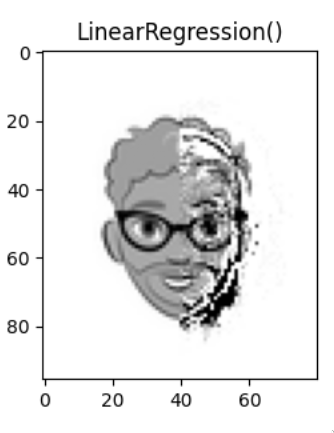

Probablement que cette forme exacte de lunettes n'était pas présente dans les données d'entraînement, et donc que notre modèle s'attendait à pouvoir utiliser un des pixels qui s'est retrouvé couvert par ces lunettes pour estimer des pixels de peau et de cheveux.

## Surapprentissage

En revérifiant l'erreur RMSE de notre régression, on peut remarquer que quelque chose cloche : **l'erreur d'entraînement est environ 15x plus faible que notre erreur de validation.**

In [13]:
df_erreurs = pd.DataFrame([
    ['RMSE entrainement', 'reg lineaire', 0.0016967125509513832],
    ['RMSE validation', 'reg lineaire', 0.026722493911353954],

    ['RMSE validation', 'KNN, K=1', 0.051065377426495306],
    ['RMSE entrainement', 'KNN, K=1', 0.0],

    ['RMSE validation', 'KNN, K=6', 0.041588415833954465],
    ['RMSE entrainement', 'KNN, K=6', 0.03536152733122336],

    ['RMSE validation', 'KNN, K=25', 0.0511518624832436],
    ['RMSE entrainement', 'KNN, K=25', 0.04986497936787545],
], columns=['type', 'variable', 'erreur'])

px.bar(df_erreurs, x='variable', y='erreur', facet_col='type')

Notre modèle a donc **très très très bien appris à donner des bonnes réponses sur le jeu de données d'entraînement**, mais l'apprentissage fait ne se généralise pas bien lorsque les nouveaux visages sont trop différents des exemples d'entraînement.

Notre régression linéaire a appris des relations un peu bizarres qui étaient spécifiques aux images d'entraînement et qui **ne se généralisent pas à autre chose**.

&nbsp;

C'est ce qu'on appelle du **surapprentissage**.

Notre régression linéaire a trouvé des mélanges de pixels qui étaient excellents quand on les teste sur le jeu d'entraînement, mais qui sont *spécifiques aux images du jeu d'entraînement*.

## Le surapprentissage en général

Paradoxalement, trop bien apprendre les données d'entraînement peut être un problème.

Trop bien apprendre le jeu de données d'entraînement va souvent mener à faire plus d'erreurs de validation.

Considérez les données suivantes :

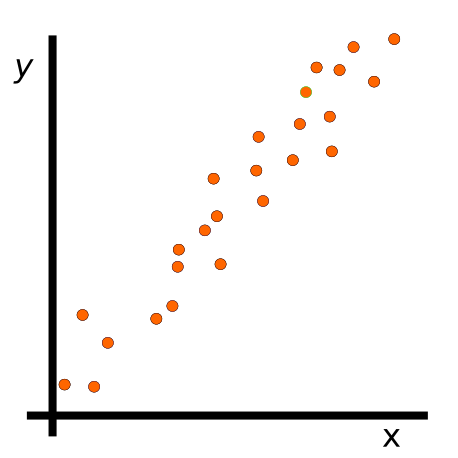

Pour apprendre et évaluer un modèle là-dessus, on doit va séparer ces données en sous-ensembles, ici par exemple, on aurait les données d'entraînement $\color{red}{\text{en rouge}}$ et les données de validation $\color{hotpink}{\text{en rose}}$ :

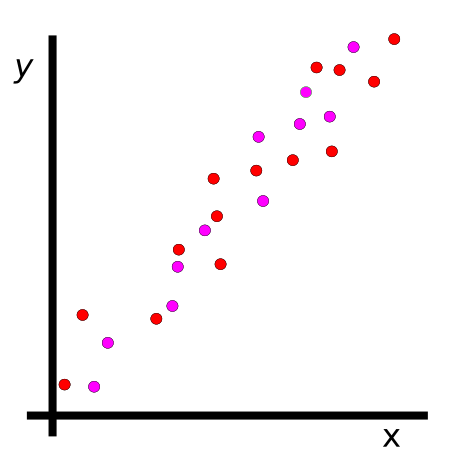

L'apprentissage d'un modèle va seulement se faire sur les données d'entraînement (en rouge). Voici deux modèles possibles :

1. En bleu, une droite de régression linéaire, qui passe au centre des points sans être toujours pile dessus
2. En vert, une courbe qui passe exactement par tous les points

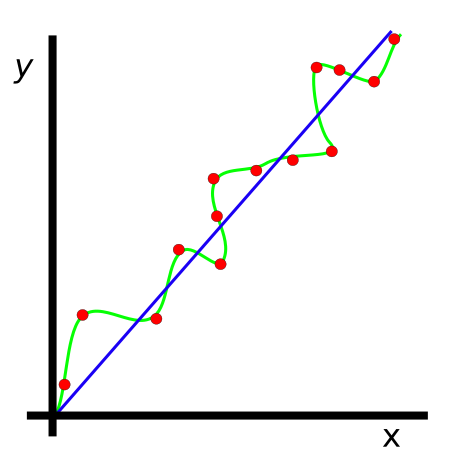

Est-ce que la courbe verte est vraiment meilleure que la bleue **en général**?

Voici ce que ça donne au moment d'évaluer les performances sur l'ensemble de validation :

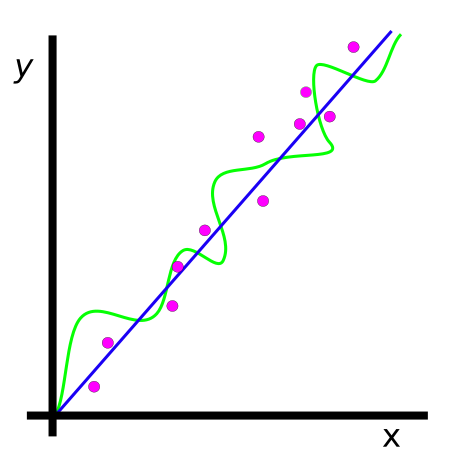

La courbe verte essaie trop fort d'aller chercher des points spécifiques qui ne sont pas forcément représentatifs de tous les points possibles.

Résultat : la droite bleue généralise mieux et performe mieux sur des nouvelles données.

**Une performance un peu plus faible sur les données d'entraînement nous permet de mieux généraliser, et donc d'avoir une meilleure performance sur les nouvelles données.**

La solution à notre problème serait donc de **forcer le modèle à être un peu moins performant sur le jeu de données d'entraînement**.

## Régularisation

La **régularisation** est le nom donné au concept de *forcer le modèle à apprendre légèrement moins bien*.

La régression linéaire simple, avec la méthode des moindres carrés qu'on utilise depuis quelques modules, tente de trouver une solution au problème :

$$\text{minimiser } \sum_{i}^N (y_i - y_{\text{prediction } i})^2$$

&nbsp;

La **Régression Ridge**, ou la régression avec une **régularisation de type L2** est une technique de régularisation qui consiste à *ajouter un terme de plus* à cette minimisation :

$$\text{minimiser } \sum_{i}^N (y_i - y_{\text{prediction } i})^2 + \alpha \sum_{i=0}^N m_i^2$$

On ajoute **la somme des coefficients au carré** dans les contraintes :

$$\alpha \sum_{i=0}^N m_i^2$$

Ici, $\alpha$ est un nombre réel positif.

**On force un certain compromis**. Lors de l'apprentissage, on veut la plus petite erreur, **tout en gardant le modèle raisonnablement simple**.

Au lieu de seulement chercher à trouver les plus petites erreurs, on cherche aussi à **garder le modèle simple**.

Pour nos dessins de visages, la régression linéaire avait l'option d'utiliser :

$$\text{pixel d'oeil droit } = \\ 15 * \text{pixel d'oeil gauche} \\ - 12 * \text{les pixels de la joue gauche} \\ + 11 * \text{les pixels de cheveux} \\ + \text{...}$$

Si on ajoute le terme de régularisation, on essaie de garder les coefficients bas, donc de privilégier ceux qui sont les plus importants plutôt que prendre tout ce qui améliore très légèrement les résultats :

$$\text{pixel d'oeil droit } = \\ 15 * \text{pixel d'oeil gauche} \\ - \color{red}{0.8} * \text{les pixels de la joue gauche} \\ + \color{red}{0.2} * \text{les pixels de cheveux} \\ + \text{...}$$

In [14]:
#@title Démo: Entraînement d'un modèle avec régularisation
from sklearn.linear_model import Ridge

modele_ridge = Ridge()

modele_ridge.fit(X_entrainement, y_entrainement)

y_predictions_validation = modele_ridge.predict(X_validation)
y_predictions_entrainement = modele_ridge.predict(X_entrainement)

print("Erreur RMSE de validation:", root_mean_squared_error(y_validation, y_predictions_validation))
print("Erreur RMSE d'entraînement:", root_mean_squared_error(y_entrainement, y_predictions_entrainement))

Erreur RMSE de validation: 0.004484345239232743
Erreur RMSE d'entraînement: 0.004154925604004138


In [15]:
df_erreurs = pd.DataFrame([
    ['RMSE entrainement', 'reg lineaire', 0.0016967125509513832],
    ['RMSE validation', 'reg lineaire', 0.026722493911353954],

    ['RMSE entrainement', 'Ridge', 0.004154925604004138],
    ['RMSE validation', 'Ridge', 0.004484345239232743],

    ['RMSE validation', 'KNN, K=1', 0.051065377426495306],
    ['RMSE entrainement', 'KNN, K=1', 0.0],

    ['RMSE validation', 'KNN, K=6', 0.041588415833954465],
    ['RMSE entrainement', 'KNN, K=6', 0.03536152733122336],

    ['RMSE validation', 'KNN, K=25', 0.0511518624832436],
    ['RMSE entrainement', 'KNN, K=25', 0.04986497936787545],
], columns=['type', 'variable', 'erreur'])

px.bar(df_erreurs, x='variable', y='erreur', facet_col='type')

On observe avec Ridge :

- L'erreur RMSE d'entraînement est plus haute qu'avant
- L'erreur RMSE de validation est plus basse

In [17]:
#@title Démo : visualisation des images générées par Ridge
def afficher_prediction_ridge(i=33):
  fig, axarr = plt.subplots(1, 3)
  axarr[0].title.set_text(f"Attendu")
  afficher_deux_cotes(X_validation[i:i+1], y_validation[i], plt=axarr[0])

  for num, modele in enumerate([modeles[0], modele_ridge]):
    y_predictions = modele.predict(X_validation[i:i+1])
    idx = num + 1
    axarr[idx].title.set_text(f"{modele}")
    afficher_deux_cotes(X_validation[i:i+1], y_predictions[0], plt=axarr[idx])

  fig.set_figheight(15)
  fig.set_figwidth(15)
  fig.tight_layout()

output = interact(afficher_prediction_ridge, i=(0, len(X_validation)-1))

interactive(children=(IntSlider(value=33, description='i', max=999), Output()), _dom_classes=('widget-interact…

In [18]:
#@title Démo : visualisation des coefficients appris avec régularisation Ridge

def afficher_coefs(x=8, y=53):
  image_coefs = np.abs(modele_ridge.coef_[y * LARGEUR_IMG//2 + x, :])
  if (image_coefs.max() - image_coefs.min()) > 0:
    image_coefs = (image_coefs - image_coefs.min()) / (image_coefs.max() - image_coefs.min())
  image_coefs = image_coefs.reshape(HAUTEUR_IMG, LARGEUR_IMG//2)
  image_coefs = np.abs(image_coefs)
  droite = y_validation[1].reshape(HAUTEUR_IMG, LARGEUR_IMG//2).copy()
  droite[y, x-3:x+4] = 0
  droite[y-3:y+4, x] = 0
  droite[y, x] = 0
  image_coefs = np.concat([image_coefs, droite], axis=-1)
  plt.imshow(image_coefs, cmap="gray")
  plt.show()

out = interact(
  afficher_coefs,
  x=(0, LARGEUR_IMG//2-1),
  y=(0, HAUTEUR_IMG-1)
)

interactive(children=(IntSlider(value=8, description='x', max=39), IntSlider(value=53, description='y', max=95…

## L'hyperparamètre $\alpha$

Notez dans la formule de la régression Ridge : $\alpha$ est un nombre à choisir, un peu comme le $K$ du KNN. C'est un **hyperparamètre**.

Comment on choisit cette valeur?

On en teste plusieurs et on garde celle qui donne les meilleurs résultats sur l'ensemble de validation.

In [20]:
#@title Exercice 4
from sklearn.linear_model import Ridge

# Entraînez 10 régressions Ridge avec des paramètres alpha différents :
# utilisez np.linspace pour tester 10 régressions allant de alpha=0.1 à alpha=3

# Tentez ensuite de trouver le meilleur alpha possible pour minimiser
# l'erreur RMSE de validation

############

for alpha in np.linspace(0.1, 3, 10):
  modele_ridge = Ridge(alpha)
  modele_ridge.fit(X_entrainement, y_entrainement)
  y_predictions_validation = modele_ridge.predict(X_validation)
  y_predictions_entrainement = modele_ridge.predict(X_entrainement)
  print("===", alpha, "===")

  print("Erreur RMSE de validation:", root_mean_squared_error(y_validation, y_predictions_validation))
  print("Erreur RMSE d'entraînement:", root_mean_squared_error(y_entrainement, y_predictions_entrainement))

# On devrait voir qu'un alpha très bas dans notre cas fonctionne bien
# On pourrait refaire une recherche d'un alpha entre 0 et 0.1 pour trouver
# une valeur plus précise

=== 0.1 ===
Erreur RMSE de validation: 0.003478881341945952
Erreur RMSE d'entraînement: 0.003013917379678919
=== 0.42222222222222217 ===
Erreur RMSE de validation: 0.00395062217931745
Erreur RMSE d'entraînement: 0.003567871104308016
=== 0.7444444444444444 ===
Erreur RMSE de validation: 0.0042679149928275
Erreur RMSE d'entraînement: 0.003921069196987476
=== 1.0666666666666667 ===
Erreur RMSE de validation: 0.004537417635282259
Erreur RMSE d'entraînement: 0.004211554905417771
=== 1.3888888888888888 ===
Erreur RMSE de validation: 0.004778747633275012
Erreur RMSE d'entraînement: 0.004466103736854484
=== 1.711111111111111 ===
Erreur RMSE de validation: 0.004999862030635956
Erreur RMSE d'entraînement: 0.004695788331349324
=== 2.033333333333333 ===
Erreur RMSE de validation: 0.005205185945944855
Erreur RMSE d'entraînement: 0.0049066712403621985
=== 2.3555555555555556 ===
Erreur RMSE de validation: 0.005397599356917585
Erreur RMSE d'entraînement: 0.0051025909923673
=== 2.6777777777777776 ===
E

# En résumé

- Le terme *régression* s'applique à n'importe quelle situation où on tente de prédire des valeurs continues ou ordonnées. Prédire des valeurs de pixels, c'est inclus là-dedans.
- Paramètre vs Hyperparamètres:
    - Un **paramètre** est une valeur apprise pendant l'entraînement d'un modèle, à partir des données d'entraînement
    - Un **hyperparamètre** est une valeur spécifiée avant de commencer l'entraînement. Ça inclut le $K$ du KNN, qui n'est pas appris.
- Sélection de modèle : on entraîne plusieurs modèles potentiellement intéressants avec différentes configurations d'hyperparamètres, et on regarde ce qui donne les meilleurs résultats sur l'ensemble de validation
- On cherche toujours à comparer nos modèles avec une *baseline*. Un algorithme classique simple peut faire office de baseline quand le problème s'y prête bien.
- Surapprentissage : trop bien apprendre l'ensemble d'entraînement peut mener à mal généraliser pour des nouvelles données
- Régularisation : certaines méthodes permettent de **garder le modèle simple**.
  - La régression Ridge vise à minimiser l'erreur au carré, **tout en limitant la valeur des coefficients appris**.